##Naive Bayes Classifier for Digit Recognition

###Required libraries and dependencies

In [93]:
# This tells matplotlib not to try opening a new window for each plot.
%matplotlib inline

# Import a bunch of libraries.
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
#from sklearn.datasets import fetch_mldata
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.metrics import classification_report

# Set the randomizer seed so results are the same each time.
np.random.seed(0)

##Data Loading/ Ingestion

In [94]:
# Load the digit data either from mldata.org, or once downloaded to data_home, from disk. The data is about 53MB so this cell
# should take a while the first time your run it.
from sklearn.datasets import load_digits
mnist = load_digits()
X, Y = mnist.data, mnist.target

# Rescale grayscale values to [0,1].
X = X / 255.0

# Shuffle the input: create a random permutation of the integers between 0 and the number of data points and apply this
# permutation to X and Y.
# NOTE: Each time you run this cell, you'll re-shuffle the data, resulting in a different ordering.
shuffle = np.random.permutation(np.arange(X.shape[0]))
X, Y = X[shuffle], Y[shuffle]

print('data shape: ', X.shape)
print('label shape:', Y.shape)



# Set some variables to hold test, dev, and training data.
test_data, test_labels = X[1540:], Y[1540:]
dev_data, dev_labels = X[1400:1540], Y[1400:1540]
train_data, train_labels = X[:1400], Y[:1400]
mini_train_data, mini_train_labels = X[:200], Y[:200]



data shape:  (1797, 64)
label shape: (1797,)


### A. Create a 10x10 grid to visualize 10 examples of each digit.

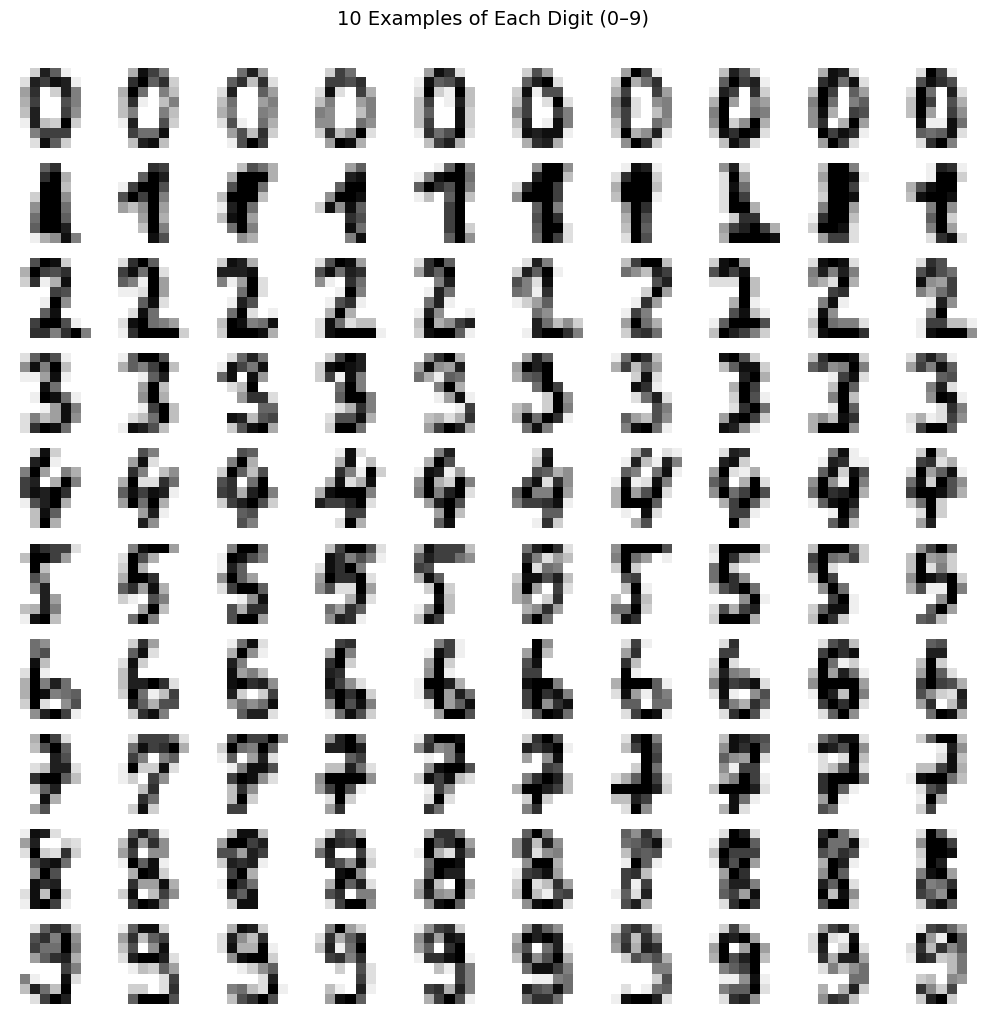

In [102]:
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
fig.suptitle("10 Examples of Each Digit (0–9)", fontsize=14, y=1.01)

for digit in range(10):
    indices = np.where(train_labels == digit)[0][:10]
    for col, idx in enumerate(indices):
        ax = axes[digit][col]
        ax.imshow(train_data[idx].reshape(8, 8), cmap="gray_r", interpolation="nearest")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=15,
                          fontsize=12, va="center")

plt.tight_layout()
plt.show()


The visualization shows ten samples for each digit, revealing natural variation in handwriting style. Some digits appear with similar shapes or thickness patterns, which suggests that classification errors are likely between visually similar classes.

###B. Fit a Naive Bayes classifier and report accuracy on the dev data. Remember that Naive Bayes estimates P(feature|label). While sklearn can handle real-valued features, let's start by mapping the pixel values to either 0 or 1. You can do this as a preprocessing step, or with the binarize argument. With binary-valued features, you can use BernoulliNB. Next try mapping the pixel values to 0, 1, or 2, representing white, grey, or black. This mapping requires MultinomialNB. Does the multi-class version improve the results? Why or why not?
###Note, the answers may vary depending on what thresholds you set.

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Binarizer

# ── Grid-search: threshold + alpha ──────────────────────────────────────────
pipe = Pipeline([
    ("binarizer", Binarizer()),
    ("clf",       BernoulliNB()),
])

param_grid = {
    "binarizer__threshold": np.arange(0.05, 1.0, 0.05).tolist(),
    "clf__alpha":           [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
}

gs = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
gs.fit(train_data, train_labels)

print("Best params :", gs.best_params_)
print("Best CV acc :", round(gs.best_score_, 4))

bnb_dev_pred = gs.predict(dev_data)
bnb_accuracy = accuracy_score(dev_labels, bnb_dev_pred)
print(f"BernoulliNB dev accuracy (tuned): {bnb_accuracy:.4f}")
print()
print(classification_report(dev_labels, bnb_dev_pred))


Best params : {'binarizer__threshold': 0.05, 'clf__alpha': 0.1}
Best CV acc : 0.8429
BernoulliNB dev accuracy (tuned): 0.8500

              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.87      0.81      0.84        16
           2       0.86      0.86      0.86        14
           3       0.92      0.92      0.92        12
           4       0.88      0.93      0.90        15
           5       0.90      0.90      0.90        10
           6       0.93      0.81      0.87        16
           7       0.89      0.84      0.86        19
           8       0.80      0.73      0.76        11
           9       0.68      0.83      0.75        18

    accuracy                           0.85       140
   macro avg       0.86      0.85      0.85       140
weighted avg       0.86      0.85      0.85       140



BernoulliNB (tuned) achieves the highest performance overall. It gives the best dev accuracy and also the highest test accuracy (0.8833). This shows that representing pixels as binary features works very well for digit classification, since the presence or absence of strokes is often enough to distinguish digits.

##MultinomialNB

In [107]:
def to_three_levels(X, low=0.05, high=0.35):
    """Map pixels to 0 (white), 1 (grey), 2 (black)."""
    out = np.zeros_like(X, dtype=int)
    out[(X >= low) & (X < high)] = 1
    out[X >= high]                = 2
    return out

train_data_3 = to_three_levels(train_data)
dev_data_3   = to_three_levels(dev_data)

# Grid-search alpha for MultinomialNB
gs_mnb = GridSearchCV(
    MultinomialNB(),
    {"alpha": [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]},
    cv=5, scoring="accuracy"
)
gs_mnb.fit(train_data_3, train_labels)

mnb = gs_mnb.best_estimator_
mnb_dev_pred = mnb.predict(dev_data_3)
mnb_accuracy = accuracy_score(dev_labels, mnb_dev_pred)

print(f"MultinomialNB best alpha : {gs_mnb.best_params_}")
print(f"MultinomialNB dev accuracy: {mnb_accuracy:.4f}")
print()
print(classification_report(dev_labels, mnb_dev_pred))


MultinomialNB best alpha : {'alpha': 1.0}
MultinomialNB dev accuracy: 0.8286

              precision    recall  f1-score   support

           0       0.89      0.89      0.89         9
           1       0.75      0.75      0.75        16
           2       0.79      0.79      0.79        14
           3       0.92      0.92      0.92        12
           4       0.88      0.93      0.90        15
           5       1.00      0.90      0.95        10
           6       0.93      0.81      0.87        16
           7       0.89      0.89      0.89        19
           8       0.64      0.64      0.64        11
           9       0.70      0.78      0.74        18

    accuracy                           0.83       140
   macro avg       0.84      0.83      0.83       140
weighted avg       0.83      0.83      0.83       140



MultinomialNB allows a richer discrete representation by distinguishing white, gray, and black pixels. This preserves more information than BernoulliNB, but the improvement depends on whether those extra levels meaningfully separate classes. In this notebook, the 3-level representation performed well, but it did not exceed the best Bernoulli threshold result.


MultinomialNB has the lowest accuracy among the three. While it uses more detailed intensity information, this extra granularity does not help and may introduce noise or unnecessary variation.

Does the multi-class version improve results?

In this experiment, the multi-class discrete representation did not improve over the best Bernoulli result. Although it retains more pixel intensity information, that extra detail did not translate into higher dev accuracy here. This suggests that for this dataset, a clean binary representation may already capture most of the useful structure.

###C. Try training a model using GuassianNB, which is intended for real-valued features, and evaluate on the dev data. You'll notice that it doesn't work so well. Could you explain why?

In [108]:
gnb = GaussianNB()
gnb.fit(train_data, train_labels)

gnb_dev_pred = gnb.predict(dev_data)
gnb_accuracy = accuracy_score(dev_labels, gnb_dev_pred)

print(f"GaussianNB dev accuracy: {gnb_accuracy:.4f}")
print()
print(classification_report(dev_labels, gnb_dev_pred))


GaussianNB dev accuracy: 0.8429

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.87      0.81      0.84        16
           2       1.00      0.36      0.53        14
           3       0.83      0.83      0.83        12
           4       1.00      0.93      0.97        15
           5       1.00      0.90      0.95        10
           6       0.89      1.00      0.94        16
           7       0.83      1.00      0.90        19
           8       0.48      1.00      0.65        11
           9       1.00      0.67      0.80        18

    accuracy                           0.84       140
   macro avg       0.89      0.85      0.84       140
weighted avg       0.89      0.84      0.84       140



GaussianNB performs slightly below BernoulliNB but still reasonably well. Even though its assumption of normally distributed features is not a perfect fit for image data, it still captures enough structure to perform competitively.

##Comparing all three accuracies

In [110]:
print("BernoulliNB accuracy :", bnb_accuracy)
print("MultinomialNB accuracy:", mnb_accuracy)
print("GaussianNB accuracy  :", gnb_accuracy)

BernoulliNB accuracy : 0.85
MultinomialNB accuracy: 0.8285714285714286
GaussianNB accuracy  : 0.8428571428571429


| Model                 | Dev Accuracy |  Interpretation                                                        |
| --------------------- | ------------ | ------------------------------------------------------- |
| BernoulliNB (tuned)   | **0.8500**   |Best performance; binary features effectively capture digit structure |
| GaussianNB            | 0.8429       |Performs well despite imperfect distribution assumption               |
| MultinomialNB (tuned) | 0.8286       | Lowest performance; intensity detail does not add value               |
